# Smart Personal Finance Analytics — Data Cleaning & EDA

**Author:** Asya
**Dataset:** `data/finance.csv` — 2025 personal financial transactions

This notebook performs:
1. Data loading & inspection
2. Data cleaning (missing values, duplicates, inconsistent labels)
3. Exploratory Data Analysis (EDA)
4. Export of cleaned dataset for Power BI dashboard


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style("whitegrid")

df = pd.read_csv("../data/finance.csv")
df.head()

,TransactionID,Date,Type,Category,SubCategory,Amount,PaymentMethod,Merchant
0,TXN0001,2025-01-01,Income,Salary,Monthly Salary,32050.02,Bank Transfer,TechCorp A.S.
1,TXN0002,2025-01-01,Expense,Savings,Mutual Fund,-1190.11,Cash,Garanti BBVA
2,TXN0003,2025-01-01,Expense,Education,Book,-62.99,Cash,Coursera
3,TXN0004,2025-01-01,Expense,Food,Restaurant,-271.97,Debit Card,Starbucks
4,TXN0005,2025-01-01,Expense,Housing,Rent,-8500.00,Bank Transfer,Landlord


## 1. Initial Data Inspection

In [2]:
print(f"Shape: {df.shape}")
df.info()

Shape: (854, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 854 entries, 0 to 853
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TransactionID  854 non-null    object 
 1   Date           854 non-null    object 
 2   Type           854 non-null    object 
 3   Category       854 non-null    object 
 4   SubCategory    854 non-null    object 
 5   Amount         854 non-null    float64
 6   PaymentMethod  837 non-null    object 
 7   Merchant       841 non-null    object 
dtypes: float64(1), object(7)
memory usage: 53.5+ KB


In [3]:
df.describe(include='all')

,TransactionID,Date,Type,Category,SubCategory,Amount,PaymentMethod,Merchant
count,854,854,854,854,854,854.000000,837,841
unique,850,327,2,13,28,NaN,4,36
top,TXN0109,2025-12-11,Expense,Food,Restaurant,NaN,Cash,Starbucks
freq,2,8,837,243,90,NaN,294,57
mean,NaN,NaN,NaN,NaN,NaN,142.983829,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,4195.957913,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,-8500.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,-313.237500,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,-194.440000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,-108.295000,NaN,NaN


## 2. Data Quality Check

Before any analysis, we need to check for the typical issues real-world
financial data has: missing values, duplicate records, and inconsistent
category labels.

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})

,Missing Count,Missing %
TransactionID,0,0.00
Date,0,0.00
Type,0,0.00
Category,0,0.00
SubCategory,0,0.00
Amount,0,0.00
PaymentMethod,17,1.99
Merchant,13,1.52


In [5]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")
df[df.duplicated(keep=False)].sort_values('TransactionID').head()

Duplicate rows: 4


,TransactionID,Date,Type,Category,SubCategory,Amount,PaymentMethod,Merchant
106,TXN0109,2025-02-16,Expense,Shopping,Home,-87.31,Debit Card,Zara
107,TXN0109,2025-02-16,Expense,Shopping,Home,-87.31,Debit Card,Zara
145,TXN0147,2025-03-02,Expense,Shopping,Electronics,-114.15,Cash,Trendyol
146,TXN0147,2025-03-02,Expense,Shopping,Electronics,-114.15,Cash,Trendyol
203,TXN0202,2025-03-28,Income,Salary,Monthly Salary,33072.46,Bank Transfer,TechCorp A.S.


In [6]:
print("Unique Category values BEFORE cleaning:")
print(sorted(df['Category'].unique()))

Unique Category values BEFORE cleaning:
['Education', 'Entertainment', 'Food', 'Freelance', 'Health', 'Housing', 'Personal Care', 'Salary', 'Savings', 'Shopping', 'Transportation', 'Utilities', 'food']


## 3. Data Cleaning

Steps performed:
- Standardize category labels (e.g. `food` → `Food`)
- Remove duplicate transactions
- Fill missing `PaymentMethod` and `Merchant` with `"Unknown"`
- Convert `Date` column to datetime and extract `Month` / `MonthName`


In [7]:
df_clean = df.copy()

# Standardize category casing
df_clean['Category'] = df_clean['Category'].str.strip().str.title()

# Remove exact duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {before - len(df_clean)} duplicate rows")

# Fill missing categorical fields
df_clean['PaymentMethod'] = df_clean['PaymentMethod'].fillna('Unknown')
df_clean['Merchant'] = df_clean['Merchant'].fillna('Unknown')

# Convert date and extract time features
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['MonthName'] = df_clean['Date'].dt.strftime('%B')

print(f"Final shape after cleaning: {df_clean.shape}")
df_clean.head()

Removed 4 duplicate rows
Final shape after cleaning: (850, 10)


,TransactionID,Date,Type,Category,SubCategory,Amount,PaymentMethod,Merchant,Month,MonthName
0,TXN0001,2025-01-01,Income,Salary,Monthly Salary,32050.02,Bank Transfer,TechCorp A.S.,1,January
1,TXN0002,2025-01-01,Expense,Savings,Mutual Fund,-1190.11,Cash,Garanti BBVA,1,January
2,TXN0003,2025-01-01,Expense,Education,Book,-62.99,Cash,Coursera,1,January
3,TXN0004,2025-01-01,Expense,Food,Restaurant,-271.97,Debit Card,Starbucks,1,January
4,TXN0005,2025-01-01,Expense,Housing,Rent,-8500.00,Bank Transfer,Landlord,1,January


In [8]:
print("Unique Category values AFTER cleaning:")
print(sorted(df_clean['Category'].unique()))
print()
print("Remaining missing values:")
print(df_clean.isnull().sum())

Unique Category values AFTER cleaning:
['Education', 'Entertainment', 'Food', 'Freelance', 'Health', 'Housing', 'Personal Care', 'Salary', 'Savings', 'Shopping', 'Transportation', 'Utilities']

Remaining missing values:
TransactionID    0
Date             0
Type             0
Category         0
SubCategory      0
Amount           0
PaymentMethod    0
Merchant         0
Month            0
MonthName        0
dtype: int64


## 4. Exploratory Data Analysis (EDA)

### 4.1 Monthly Income vs Expense

In [9]:
monthly = df_clean.groupby(['Month', 'MonthName', 'Type'])['Amount'].sum().reset_index()
monthly_pivot = monthly.pivot(index=['Month', 'MonthName'], columns='Type', values='Amount').fillna(0)
monthly_pivot['Expense'] = monthly_pivot['Expense'].abs()
monthly_pivot['Savings'] = monthly_pivot['Income'] - monthly_pivot['Expense']
monthly_pivot = monthly_pivot.reset_index().sort_values('Month')
monthly_pivot

Type,Month,MonthName,Expense,Income,Savings
0,1,January,25057.82,35453.55,10395.73
1,2,February,22665.22,33178.53,10513.31
2,3,March,26548.15,35427.00,8878.85
3,4,April,23709.08,33835.01,10125.93
4,5,May,22944.68,33610.09,10665.41
5,6,June,27023.01,33994.65,6971.64
6,7,July,28475.45,39032.75,10557.30
7,8,August,27401.54,32305.68,4904.14
8,9,September,26588.66,32256.78,5668.12
9,10,October,27665.42,32676.17,5010.75


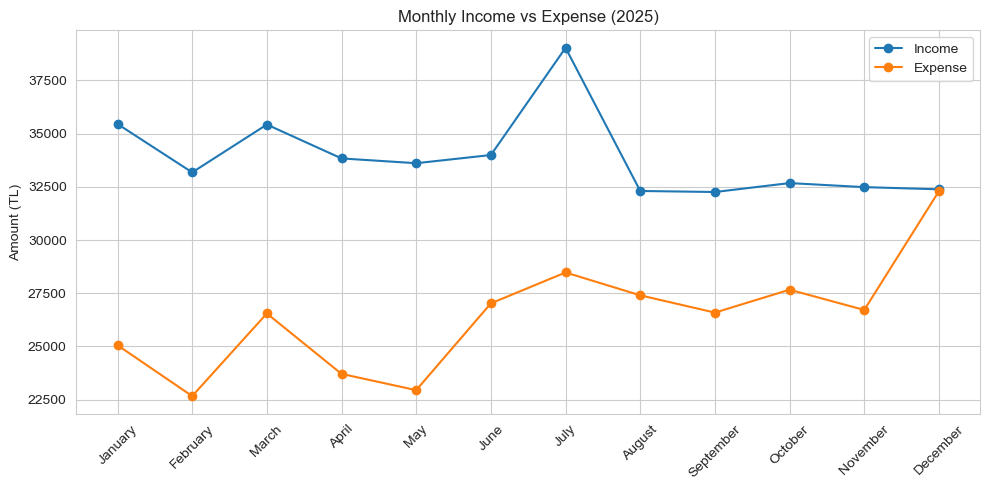

In [10]:
fig, ax = plt.subplots()
ax.plot(monthly_pivot['MonthName'], monthly_pivot['Income'], marker='o', label='Income')
ax.plot(monthly_pivot['MonthName'], monthly_pivot['Expense'], marker='o', label='Expense')
ax.set_title('Monthly Income vs Expense (2025)')
ax.set_ylabel('Amount (TL)')
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('../images/monthly_income_expense.png', dpi=150)
plt.show()

### 4.2 Expense Breakdown by Category

In [11]:
category_totals = (
    df_clean[df_clean['Type'] == 'Expense']
    .groupby('Category')['Amount']
    .sum()
    .abs()
    .sort_values(ascending=False)
)
category_pct = (category_totals / category_totals.sum() * 100).round(1)
pd.DataFrame({'Total Spent (TL)': category_totals.round(2), '% of Total': category_pct})

,Total Spent (TL),% of Total
Category,,
Housing,102000.00,32.2
Savings,50521.61,15.9
Shopping,46239.73,14.6
Food,38097.20,12.0
Entertainment,23375.15,7.4
Transportation,19518.06,6.2
Education,17072.70,5.4
Personal Care,8188.18,2.6
Health,7174.78,2.3


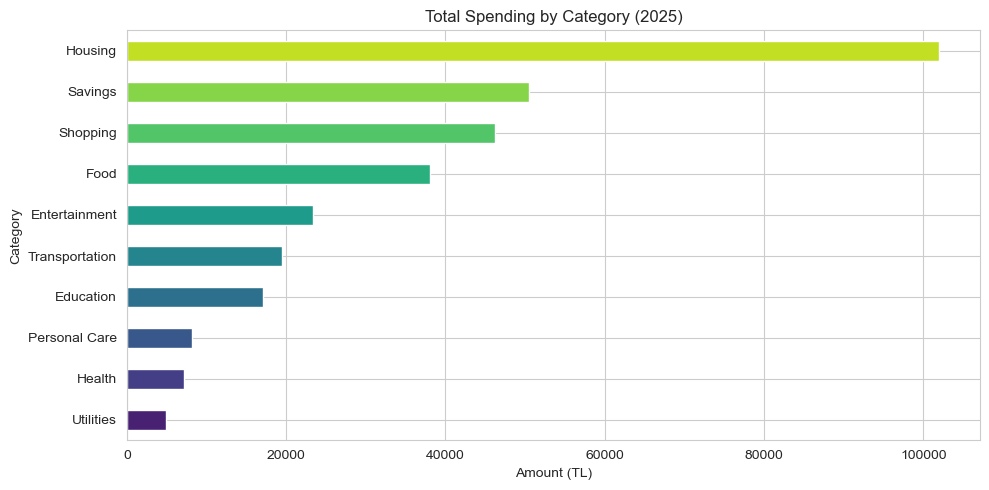

In [12]:
fig, ax = plt.subplots()
category_totals.sort_values().plot(kind='barh', ax=ax, color=sns.color_palette("viridis", len(category_totals)))
ax.set_title('Total Spending by Category (2025)')
ax.set_xlabel('Amount (TL)')
plt.tight_layout()
plt.savefig('../images/category_breakdown.png', dpi=150)
plt.show()

### 4.3 Payment Method Distribution

In [13]:
payment_dist = (
    df_clean[df_clean['Type'] == 'Expense']
    .groupby('PaymentMethod')['Amount']
    .sum()
    .abs()
    .sort_values(ascending=False)
)
payment_dist

PaymentMethod
Bank Transfer    93500.00
Cash             75877.32
Debit Card       71190.51
Credit Card      62729.37
Unknown          13791.19
Name: Amount, dtype: float64

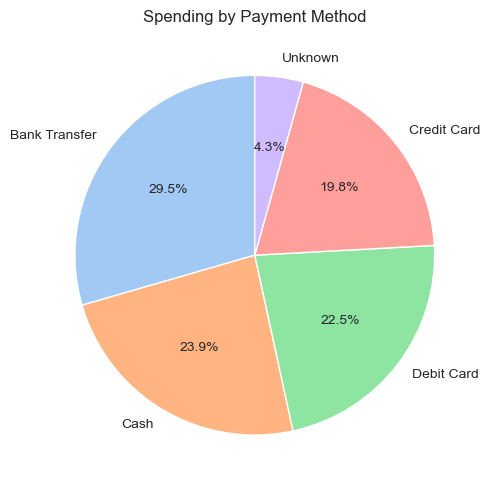

In [14]:
fig, ax = plt.subplots()
ax.pie(payment_dist, labels=payment_dist.index, autopct='%1.1f%%', startangle=90,
       colors=sns.color_palette("pastel"))
ax.set_title('Spending by Payment Method')
plt.tight_layout()
plt.savefig('../images/payment_method.png', dpi=150)
plt.show()

### 4.4 Most Expensive Month

In [15]:
most_expensive_month = monthly_pivot.loc[monthly_pivot['Expense'].idxmax()]
print(f"Most expensive month: {most_expensive_month['MonthName']} "
      f"with {most_expensive_month['Expense']:,.2f} TL in expenses")

Most expensive month: December with 32,296.10 TL in expenses


### 4.5 Average Monthly Spending & Savings Rate

In [16]:
avg_monthly_expense = monthly_pivot['Expense'].mean()
avg_monthly_income = monthly_pivot['Income'].mean()
avg_savings_rate = (monthly_pivot['Savings'].sum() / monthly_pivot['Income'].sum()) * 100

print(f"Average Monthly Income:  {avg_monthly_income:,.2f} TL")
print(f"Average Monthly Expense: {avg_monthly_expense:,.2f} TL")
print(f"Overall Savings Rate:    {avg_savings_rate:.1f}%")

Average Monthly Income:  33,886.61 TL
Average Monthly Expense: 26,424.03 TL
Overall Savings Rate:    22.0%


### 4.6 Top Merchants

In [ ]:
top_merchants = (
    df_clean[df_clean['Type'] == 'Expense']
    .groupby('Merchant')['Amount']
    .sum()
    .abs()
    .sort_values(ascending=False)
    .head(10)
)
top_merchants

Merchant
Landlord        102000.00
Garanti BBVA     27602.38
IsYatirim        22919.23
Zara             12819.93
MediaMarkt       11276.77
IKEA             11029.26
Trendyol         10741.26
CarrefourSA       9948.33
Starbucks         7909.42
Getir             7876.11
Name: Amount, dtype: float64

## 5. Export Cleaned Dataset

Save the cleaned dataset for use in the Power BI dashboard.

In [18]:
df_clean.to_csv('../data/finance_cleaned.csv', index=False)
print("Saved: data/finance_cleaned.csv")

Saved: data/finance_cleaned.csv


## 6. Key Findings (Draft Business Insights)

- En yüksek harcama kategorisi: **[buraya doldur]**, toplam harcamanın **%[X]**'i
- En masraflı ay: **[buraya doldur]**
- Genel tasarruf oranı: **%[X]**
- Ödeme yöntemi tercihi: **[buraya doldur]**
